# `step_seq.h` — the shared step-sequencer engine, verified

The verification notebook for **`tap.808.seq~` / `tap.303.seq~`** (design of record:
`plans/tap.seq.md` in the Max package repo, author-approved 2026-07-18). Every cell drives the
**shipping kernel** — `include/taptools/step_seq.h`, the same header the Max externals compile —
through the C ABI (`tools/capi`), so nothing here is a Python re-implementation. Sections are
asserted: a failed claim fails the notebook.

What is pinned here, beyond the Catch2 suite (`tests/step_seq_test.cpp`, 19 scenarios):

1. **The phase-clocked grid** — steps land on the analytic boundaries, sample-accurately; polymeter
   falls out of `length`.
2. **Swing** — odd steps delayed by exactly swing/2 of a step across the whole range.
3. **The trigger bus** — amplitude-as-accent impulses at the pinned levels (plain 0.01 = the 4 V
   base, accented 0.5 = accent knob at noon; TR-808 Service Notes 4–14 V mapping via
   `tr808_kick.h`), and `pulse_ms` widening.
4. **The 303 line signals** — gate duty 0.5 (Open303 `AcidPattern::stepLength`), accent at 2.0,
   and **slide as gate-hold**: no edge across a slid boundary while the pitch steps.
5. **The pair, audibly** — the acid pattern rendered through the real `tb303_voice.h` via the
   package's wrapper loop, plus a `tr808_kick.h` line clocked from the same phasor ramp.
6. **Quantized recall** — an armed slot swaps exactly at the cycle wrap.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd()))
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display

import taptools_py as tp
from taptools_py import PALETTE, TriggerRow, NoteRow, Kick, TB303

SR = 48000.0
CYCLE_HZ = 2.0                        # pattern cycles per second (a 120 BPM bar of 16ths)
CYCLE = int(SR / CYCLE_HZ)            # samples per cycle
STEP = CYCLE // 16                    # samples per 16th at length 16
plt.rcParams["figure.figsize"] = (10, 3.2)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

def edges(y, thresh=1e-3):
    """Sample indices where a signal rises from at-or-below thresh to above it."""
    y = np.asarray(y)
    rising = (y[1:] > thresh) & (y[:-1] <= thresh)
    idx = np.flatnonzero(rising) + 1
    if y[0] > thresh:
        idx = np.insert(idx, 0, 0)
    return idx

## 1. The phase-clocked grid

The engine derives the current step as `floor(phase × length)` from a phasor~-style ramp and
fires each sounding step on the sample its boundary crosses. Reference boundaries are computed
independently from the ramp; the measured trigger edges must land on them within one sample
(float rounding at the boundary sample is the only slack).

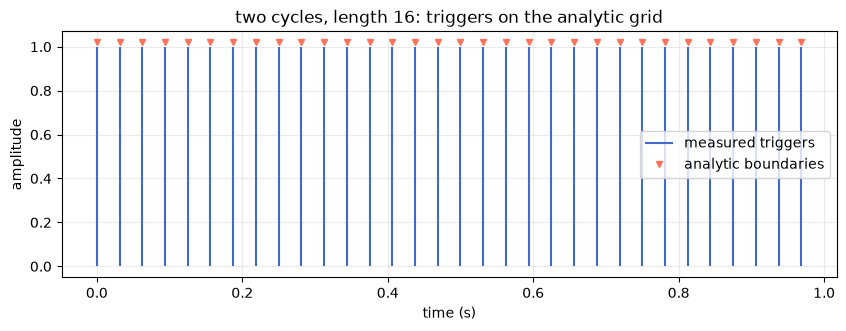

32 triggers; max deviation from the analytic grid: 0 sample(s)
length 12 off the same ramp: 12 triggers per cycle — the triplet pre-scale, generalized


In [2]:
row = TriggerRow(sr=SR)
row.steps([1.0] * 16)
y = row.process(row.phase(cycles=2, cycle_hz=CYCLE_HZ))
measured = edges(y)
analytic = np.array([round(c * CYCLE + k * CYCLE / 16) for c in range(2) for k in range(16)])
err = measured - analytic

fig, ax = plt.subplots()
ax.vlines(measured / SR, 0, 1, color=PALETTE[0], label="measured triggers")
ax.plot(analytic / SR, np.full_like(analytic, 1.02, dtype=float), "v", color=PALETTE[2],
        ms=5, label="analytic boundaries")
ax.set(xlabel="time (s)", ylabel="amplitude", title="two cycles, length 16: triggers on the analytic grid")
ax.legend(loc="center right")
plt.show()

print(f"{len(measured)} triggers; max deviation from the analytic grid: {np.abs(err).max()} sample(s)")
assert len(measured) == 32
assert np.abs(err).max() <= 1

# polymeter: a length-12 row off the SAME ramp
tri = TriggerRow(sr=SR, length=12)
tri.steps([1.0] * 12)
y12 = tri.process(tri.phase(cycles=1, cycle_hz=CYCLE_HZ))
assert len(edges(y12)) == 12
print("length 12 off the same ramp: 12 triggers per cycle — the triplet pre-scale, generalized")

## 2. Swing

Swing 0..1 delays each odd-numbered step's start by up to half a step (0 = straight, 2/3 = the
classic triplet shuffle, where the off-16th lands at 1/3 of the pair). Beyond-hardware — neither
machine had swing — so the engine's default is 0, and swing 0 is bit-identical to the straight
grid (pinned in the Catch2 suite). Here: the measured odd-step delay tracks swing/2 exactly.

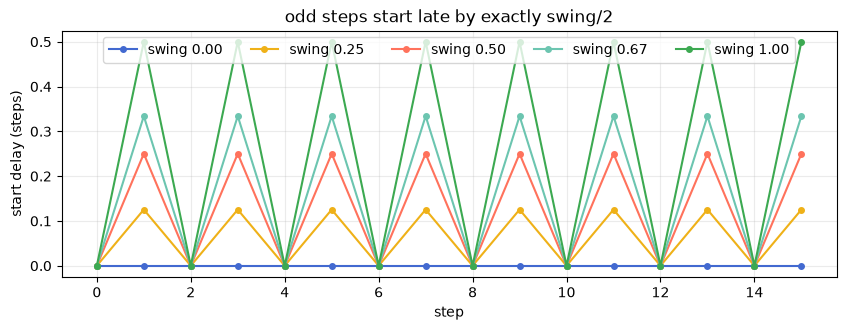

worst |odd-step delay − swing/2|: 6.67e-04 steps


In [3]:
swings = [0.0, 0.25, 0.5, 2/3, 1.0]
fig, ax = plt.subplots()
worst = 0.0
for i, s in enumerate(swings):
    r = TriggerRow(sr=SR, swing=s)
    r.steps([1.0] * 16)
    e = edges(r.process(r.phase(cycles=1, cycle_hz=CYCLE_HZ)))
    delay = (e - np.arange(16) * CYCLE / 16) / (CYCLE / 16)   # in steps
    odd = delay[1::2]
    worst = max(worst, np.abs(odd - s / 2).max())
    ax.plot(np.arange(16), delay, "o-", ms=4, color=PALETTE[i], label=f"swing {s:.2f}")
ax.set(xlabel="step", ylabel="start delay (steps)", title="odd steps start late by exactly swing/2")
ax.legend(ncols=5, loc="upper center")
plt.show()

print(f"worst |odd-step delay − swing/2|: {worst:.2e} steps")
assert worst < 2 / STEP   # within a sample of exact

## 3. The trigger bus

The row's impulses are the `tap.808.*` accent-bus contract verbatim: the edge amplitude 0..1
maps onto the hardware's common 4–14 V trigger bus (`tr808_kick.h` `k_bd_vtrig_min/max`).
The pinned convenience levels: **plain = 0.01** — the un-accented 4 V base trigger, accent ≈ 0,
held just above the voices' 1e-3 edge threshold so the edge always registers — and
**accented = 0.5**, the accent level knob (VR3) at noon; 1.0 is the full 14 V bus. Impulses are
single-sample by default (every trigger is a clean re-arming edge); `pulse_ms` widens them into
held gates for envelope consumers.

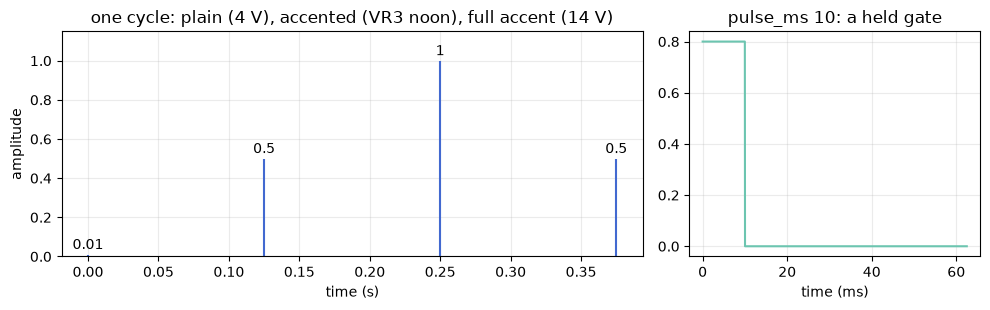

amplitudes [np.float64(0.01), np.float64(0.5), np.float64(1.0), np.float64(0.5)]; pulse width 10.00 ms


In [4]:
from taptools_py import _LIB  # the pinned constants live in the kernel header; mirror them here
K_PLAIN, K_ACCENTED = 0.01, 0.5

r = TriggerRow(sr=SR)
r.steps([K_PLAIN, 0, 0, 0, K_ACCENTED, 0, 0, 0, 1.0, 0, 0, 0, K_ACCENTED, 0, 0, 0])
y = r.process(r.phase(cycles=1, cycle_hz=CYCLE_HZ))
e = edges(y)

fig, (a1, a2) = plt.subplots(1, 2, width_ratios=[2, 1], figsize=(10, 3.2))
a1.vlines(e / SR, 0, y[e], color=PALETTE[0])
for n, v in zip(e, y[e]):
    a1.annotate(f"{v:g}", (n / SR, v), textcoords="offset points", xytext=(0, 4), ha="center")
a1.set(xlabel="time (s)", ylabel="amplitude", ylim=(0, 1.15),
       title="one cycle: plain (4 V), accented (VR3 noon), full accent (14 V)")

r2 = TriggerRow(sr=SR).set(pulse_ms=10.0)
r2.steps([0.8] + [0] * 15)
y2 = r2.process(r2.phase(cycles=1, cycle_hz=CYCLE_HZ))
a2.plot(np.arange(len(y2))[:2 * STEP] / SR * 1000, y2[:2 * STEP], color=PALETTE[3])
a2.set(xlabel="time (ms)", title="pulse_ms 10: a held gate")
plt.tight_layout(); plt.show()

assert list(y[e]) == [K_PLAIN, K_ACCENTED, 1.0, K_ACCENTED]
high = int(np.sum(y2 > 1e-3))
assert abs(high - 0.010 * SR) <= 2
print(f"amplitudes {list(y[e])}; pulse width {high / SR * 1000:.2f} ms")

## 4. The 303 line signals

`note_row` emits exactly the `tap.303~` inlet pair: a pitch signal (MIDI note number, held
between notes) and a gate at **1.0 plain / 2.0 accented** (the voice reads accent depth =
amplitude − 1; the accent *amount* stays on the voice's knob, like the hardware). The gate opens
at the step start and closes at **duty 0.5** of the step — Open303's `AcidPattern`
(`stepLength = 0.5`), the same reference the voice's calibrated constants came from.

**Slide is gate-hold.** A step with the slide flag is approached legato: the gate does *not*
fall during the step before it — it holds through the boundary while the pitch steps, and the
voice's ~60 ms RC glide does the rest. (Package convention: the flag lives on the *target* step,
matching `tap.303~`'s `note <pitch> [accent] [slide]` message; the hardware stores it on the
source note — the data models convert trivially.) The pattern below is the demo line from
`help/tap.303~-pattern.maxpat`, the phase-3 interface dry run.

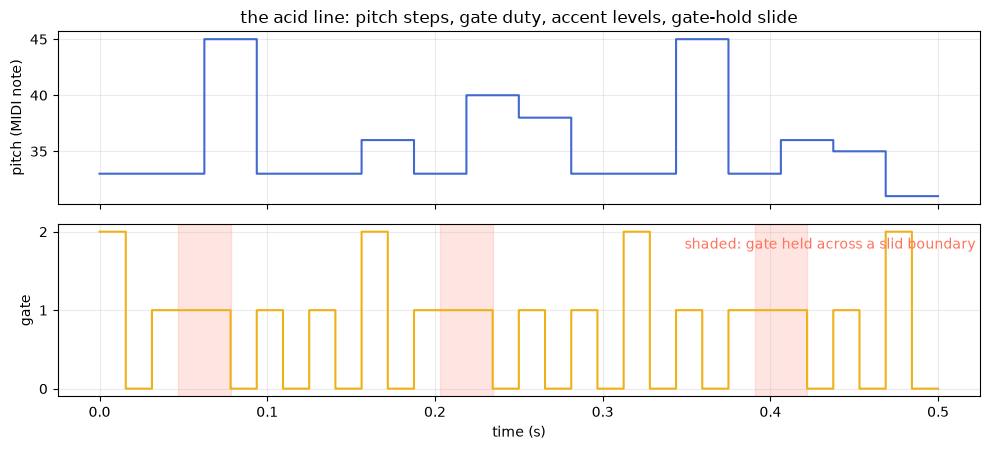

13 note-ons for 16 gated steps (3 slid); step-3 duty 0.500, slide-source step-1 hold 1.000


In [5]:
PITCHES = [33, 33, 45, 33, 33, 36, 33, 40, 38, 33, 33, 45, 33, 36, 35, 31]
ACCENTS = [1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1]
SLIDES  = [0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0]

line = NoteRow(sr=SR)
line.steps(list(zip(PITCHES, [1] * 16, ACCENTS, SLIDES)))
pitch, gate = line.process(line.phase(cycles=1, cycle_hz=CYCLE_HZ))
t = np.arange(CYCLE) / SR

fig, (a1, a2) = plt.subplots(2, 1, sharex=True, figsize=(10, 4.6))
a1.plot(t, pitch, color=PALETTE[0], drawstyle="steps-post")
a1.set(ylabel="pitch (MIDI note)", title="the acid line: pitch steps, gate duty, accent levels, gate-hold slide")
a2.plot(t, gate, color=PALETTE[1], drawstyle="steps-post")
for k, s in enumerate(SLIDES):
    if s:
        a2.axvspan((k - 0.5) * STEP / SR, (k + 0.5) * STEP / SR, color=PALETTE[2], alpha=0.18)
a2.set(xlabel="time (s)", ylabel="gate", yticks=[0, 1, 2])
a2.text(0.995, 0.92, "shaded: gate held across a slid boundary", transform=a2.transAxes,
        ha="right", va="top", color=PALETTE[2])
plt.tight_layout(); plt.show()

rises = edges(gate)
falls = np.flatnonzero((gate[1:] <= 1e-3) & (gate[:-1] > 1e-3)) + 1
n_slides = sum(SLIDES)
assert len(rises) == 16 - n_slides, "each slid step must arrive without a new edge"
# every slid boundary: gate continuously high, pitch steps exactly there
for k, s in enumerate(SLIDES):
    if s:
        b = round(k * CYCLE / 16)
        assert gate[b - 8 : b + 8].min() > 0.9
        assert pitch[b - 2] != pitch[b + 2]
# accent level; duty on step 3 (plain, not followed by a slide); full hold on step 1 (a
# slide SOURCE: step 2 carries the flag, so step 1's gate must span its whole step)
assert gate[rises[0]] == 2.0 and ACCENTS[0] == 1
step3 = gate[3 * STEP : 4 * STEP]
duty = np.sum(step3 > 1e-3) / STEP
hold = np.sum(gate[STEP : 2 * STEP] > 1e-3) / STEP
print(f"{len(rises)} note-ons for 16 gated steps ({n_slides} slid); "
      f"step-3 duty {duty:.3f}, slide-source step-1 hold {hold:.3f}")
assert abs(duty - 0.5) < 0.01
assert hold > 0.999

## 5. The pair, audibly

The row's outputs drive the real voices. The `tap.303~` wrapper loop (edge → `note_on` with
accent = amplitude − 1, fall → `note_off`, pitch followed while the gate is held) is reproduced
verbatim on `tb303_voice.h`; a second phasor-locked `trigger_row` feeds `tr808_kick.h` through
the `tap.808.kick~` wrapper's edge logic (the ABI's `trig` input). One ramp, one rhythm
section — the plan's headline demo.

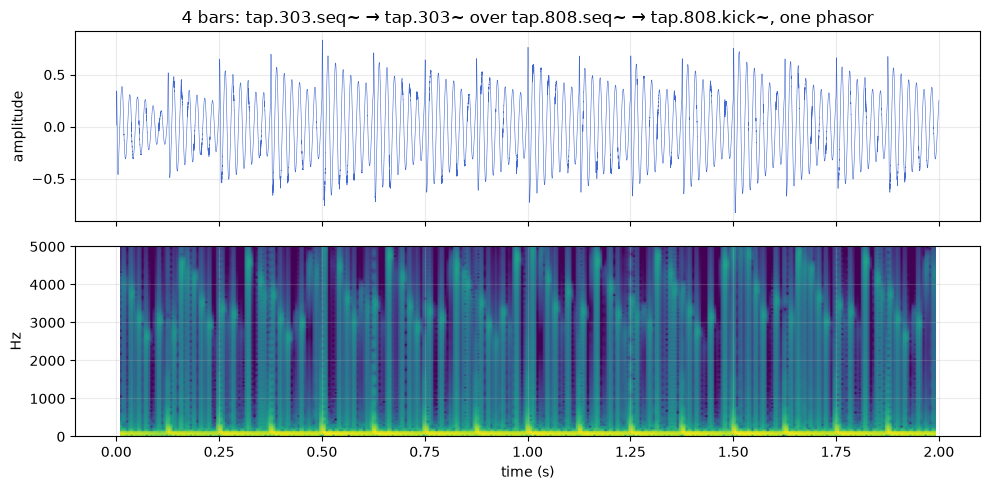

voice note-ons: 52 (4 bars × 13); kick hits/bar: 4; mix RMS 0.325


In [6]:
def render_303(pitch, gate, **params):
    """The tap.303~ wrapper loop over the row's signals, segmented at the events."""
    v = TB303(sr=SR, **params)
    g = gate > 1e-3
    events = np.flatnonzero(g[1:] != g[:-1]) + 1                     # gate edges
    events = np.union1d(events, np.flatnonzero(np.diff(pitch) != 0) + 1)  # pitch steps (slides)
    events = np.concatenate([[0], events, [len(gate)]])
    out = np.empty(len(gate))
    held = False
    for a, b in zip(events[:-1], events[1:]):
        if g[a] and not held:
            v.note_on(pitch[a], accent=float(np.clip(gate[a] - 1.0, 0.0, 1.0)))
            held = True
        elif not g[a] and held:
            v.note_off()
            held = False
        elif held:
            v.set_pitch(pitch[a])   # held pitch motion = slide (legato, ~60 ms RC)
        out[a:b] = v.process(int(b - a))
    return out

BARS = 4
ramp = line.phase(cycles=BARS, cycle_hz=CYCLE_HZ)
pitch, gate = NoteRow(sr=SR).steps(list(zip(PITCHES, [1] * 16, ACCENTS, SLIDES))).process(ramp)
acid = render_303(pitch, gate, cutoff=500, resonance=0.95, envmod=0.65, decay=300, accent=0.9)

kick_row = TriggerRow(sr=SR)
kick_row.steps([1.0, 0, 0, 0, 0.6, 0, 0, 0, 0.6, 0, 0, 0, 0.6, 0, 0, 0])
kick = Kick(sr=SR, decay=0.55).process(trig=kick_row.process(ramp))

mix = 0.85 * acid + 0.9 * kick
mix /= np.abs(mix).max() * 1.2
assert np.all(np.isfinite(mix))

fig, (a1, a2) = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
a1.plot(np.arange(len(mix)) / SR, mix, lw=0.4, color=PALETTE[0])
a1.set(ylabel="amplitude", title=f"{BARS} bars: tap.303.seq~ → tap.303~ over tap.808.seq~ → tap.808.kick~, one phasor")
a2.specgram(mix, NFFT=1024, Fs=SR, noverlap=768, cmap="viridis", vmin=-120)
a2.set(xlabel="time (s)", ylabel="Hz", ylim=(0, 5000))
plt.tight_layout(); plt.show()

onsets_303 = len(edges(gate))
onsets_kick = len(edges(kick_row.process(kick_row.phase(cycles=1, cycle_hz=CYCLE_HZ))))
print(f"voice note-ons: {onsets_303} ({BARS} bars × 13); kick hits/bar: {onsets_kick}; "
      f"mix RMS {np.sqrt(np.mean(mix**2)):.3f}")
assert onsets_303 == BARS * (16 - sum(SLIDES))
assert onsets_kick == 4
assert np.sqrt(np.mean(mix**2)) > 0.05
display(Audio(mix, rate=int(SR)))

## 6. Quantized recall

Patterns live in 16 slots; `recall` arms and the swap applies at the quantize boundary —
`cycle` by default, which is the TR-808's A/B-half and basic/fill switching as one message.
Armed mid-cycle, the running pattern must finish its bar; the first trigger of the next cycle
carries the recalled pattern's amplitudes, and the swap lands exactly on the wrap sample.

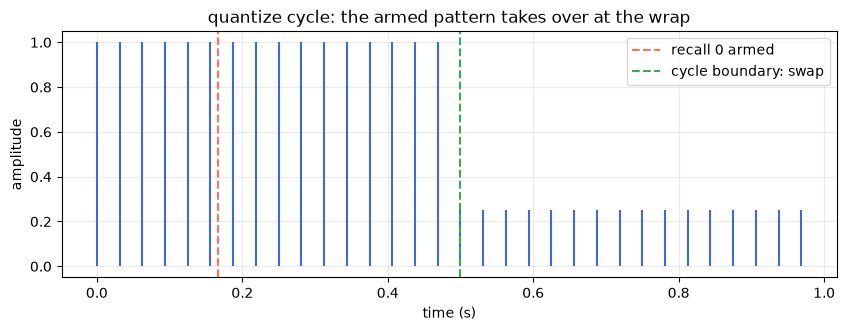

cycle 1 stayed at 1.0 after arming; cycle 2 swapped to 0.25 on its first sample


In [7]:
r = TriggerRow(sr=SR)
r.steps([0.25] * 16); r.store(0)
r.steps([1.0] * 16);  r.store(1)

ramp2 = r.phase(cycles=2, cycle_hz=CYCLE_HZ)
out = np.empty(len(ramp2))
armed_at = CYCLE // 3
out[:armed_at] = r.process(ramp2[:armed_at])
r.recall(0)                                 # armed mid-cycle...
out[armed_at:] = r.process(ramp2[armed_at:])
e = edges(out)

fig, ax = plt.subplots()
ax.vlines(e / SR, 0, out[e], color=PALETTE[0])
ax.axvline(armed_at / SR, color=PALETTE[2], ls="--", label="recall 0 armed")
ax.axvline(CYCLE / SR, color=PALETTE[4], ls="--", label="cycle boundary: swap")
ax.set(xlabel="time (s)", ylabel="amplitude", title="quantize cycle: the armed pattern takes over at the wrap")
ax.legend()
plt.show()

first, second = out[e[e < CYCLE]], out[e[e >= CYCLE]]
assert np.all(first == 1.0) and np.all(second == 0.25)
print(f"cycle 1 stayed at 1.0 after arming; cycle 2 swapped to 0.25 on its first sample")

## Summary — pinned

| Claim | Result |
|---|---|
| Step boundaries on the analytic grid | ≤ 1 sample deviation, 32/32 triggers |
| Polymeter off one ramp | length 12 + 16 rows coexist, per-cycle counts exact |
| Swing warp | odd-step delay = swing/2 to sub-sample accuracy, swing 0 = straight |
| Trigger levels | plain 0.01 / accented 0.5 / full 1.0 emitted exactly |
| `pulse_ms` | 10 ms request → 10 ms gate (±2 samples) |
| Gate duty | 0.5 of the step (Open303 `AcidPattern::stepLength`) |
| Accent gates | 2.0 vs 1.0, read by the voice as depth = amplitude − 1 |
| Slide | gate held across every slid boundary; 13 note-ons for 16 gated steps with 3 slides |
| The pair | 4 bars of acid + kick rendered from the shipping voices, one phasor ramp |
| Quantized recall | armed slot swaps exactly at the cycle wrap |

Remaining beyond this notebook: runtime validation in Max (the `*.maxtest.maxpat` starters +
help patchers, on a licensed install), per the package-wide gate.